In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import eli5

In [69]:
def read_dataframe(path):
    df = pd.read_parquet(path)
    categorical = ['PULocationID','DOLocationID','trip_type','payment_type','VendorID']
    df['duration'] = pd.to_datetime(df['lpep_dropoff_datetime'])  - pd.to_datetime(df['lpep_pickup_datetime'])
    df['duration'] = df['duration'].dt.total_seconds()
    df['duration'] = df['duration']/60
    df[categorical] = df[categorical].astype(str)
    ## focus on duration>=1 and duration<=60
    df = df[(df['duration']>=1)&(df['duration']<=60)].reset_index(drop = True)
  
    df['PU_DO'] = df['DOLocationID'] + '_' + df['PULocationID']
    
    df['trip_type'].fillna("unknown", inplace=True)
    df['payment_type'].fillna("unknown", inplace=True)
    df['passenger_count'].fillna(-1, inplace=True)

    return df


In [70]:
df = read_dataframe('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2021-01.parquet')

/tmp/ipykernel_23269/503066906.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['trip_type'].fillna("unknown", inplace=True)
/tmp/ipykernel_23269/503066906.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

In [71]:
categorical = ['PU_DO','trip_type','payment_type','VendorID'] #['PULocationID','DOLocationID','trip_type','payment_type','VendorID']
numerical= ['trip_distance','passenger_count','fare_amount']

In [72]:
train_dicts= df[categorical + numerical].to_dict(orient = 'records')

/tmp/ipykernel_23269/416187562.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred,label="prediction")
/tmp/ipykernel_23269/416187562.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train,label ="Actual")


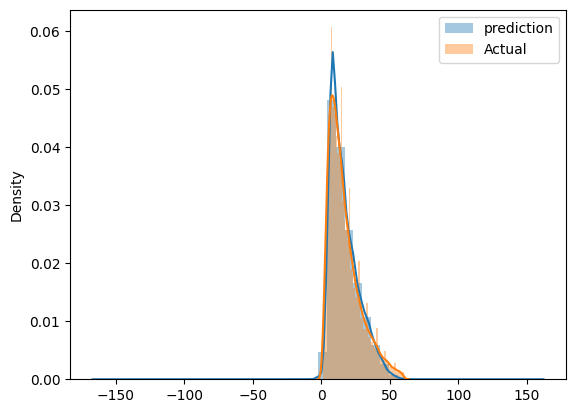

In [73]:
dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)
target = 'duration'
y_train = df[target].values
## model
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_train)
sns.distplot(y_pred,label="prediction")
sns.distplot(y_train,label ="Actual")

plt.legend()

In [74]:
def regression_metric(y_pred, y_true):
    print("RMSE" ,np.sqrt(mean_squared_error(y_pred, y_true)))
    y_mean = y_true.mean()
    print("Base line RMSE", np.sqrt(np.mean((y_pred-y_mean)**2)))
    ## R1 score
    r2_score = 1 - (np.sum((y_true-y_pred)**2)/(np.sum((y_true-y_mean)**2)))
    print("R2 Score", r2_score)

In [75]:
regression_metric(y_pred, y_train)

RMSE 4.912282521584102
Base line RMSE 10.467122593114988
R2 Score 0.819524085651925


## Validation Dataset

In [76]:
df = read_dataframe('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2021-02.parquet')
categorical = ['PU_DO','trip_type','payment_type','VendorID'] #['PULocationID','DOLocationID','trip_type','payment_type','VendorID']
numerical= ['trip_distance','passenger_count','fare_amount']
validation_dicts= df[categorical + numerical].to_dict(orient = 'records')
X_val = dv.transform(validation_dicts)
target = 'duration'
y_val = df[target].values
y_pred = lr.predict(X_val)


/tmp/ipykernel_23269/503066906.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['trip_type'].fillna("unknown", inplace=True)
/tmp/ipykernel_23269/503066906.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

/tmp/ipykernel_23269/1276451650.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred,label="prediction")
/tmp/ipykernel_23269/1276451650.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_val,label ="Actual")


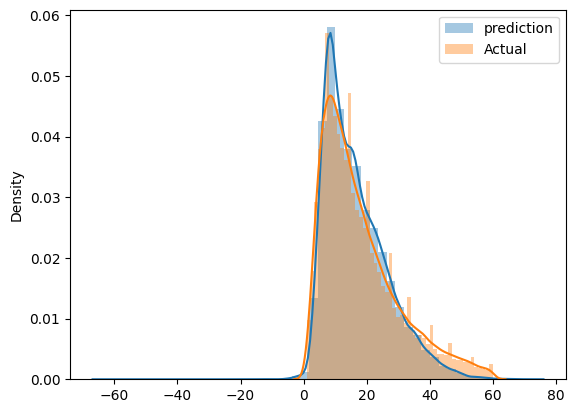

In [77]:
sns.distplot(y_pred,label="prediction")
sns.distplot(y_val,label ="Actual")

plt.legend()

In [78]:
regression_metric(y_pred, y_val)

RMSE 6.487894653710045
Base line RMSE 9.994052173431566
R2 Score 0.7159119555466333


## Saving Model

In [80]:
import pickle
with open('models/lin_reg.bin','wb') as fout:
    pickle.dump((dv,lr),fout) 

## Model Explainability

### Permutaion Importance
Which feature is most import when we do prediction

In [ ]:
## slightly better than mean
import eli5
from eli5.sklearn import PermutationImportance

perm = PermutationImportance(lr, random_state=1).fit(X_train.toarray(), y)

# Feature importance दिखाएं
eli5.show_weights(perm, feature_names=dv.get_feature_names_out())

### Partial Plots
How prediction varies with features

['DOLocationID=1', 'DOLocationID=10', 'DOLocationID=100', 'DOLocationID=101', 'DOLocationID=102', 'DOLocationID=106', 'DOLocationID=107', 'DOLocationID=108', 'DOLocationID=109', 'DOLocationID=11', 'DOLocationID=111', 'DOLocationID=112', 'DOLocationID=113', 'DOLocationID=114', 'DOLocationID=115', 'DOLocationID=116', 'DOLocationID=117', 'DOLocationID=118', 'DOLocationID=119', 'DOLocationID=12', 'DOLocationID=120', 'DOLocationID=121', 'DOLocationID=122', 'DOLocationID=123', 'DOLocationID=124', 'DOLocationID=125', 'DOLocationID=126', 'DOLocationID=127', 'DOLocationID=128', 'DOLocationID=129', 'DOLocationID=13', 'DOLocationID=130', 'DOLocationID=131', 'DOLocationID=132', 'DOLocationID=133', 'DOLocationID=134', 'DOLocationID=135', 'DOLocationID=136', 'DOLocationID=137', 'DOLocationID=138', 'DOLocationID=139', 'DOLocationID=14', 'DOLocationID=140', 'DOLocationID=141', 'DOLocationID=142', 'DOLocationID=143', 'DOLocationID=144', 'DOLocationID=145', 'DOLocationID=146', 'DOLocationID=147', 'DOLoc

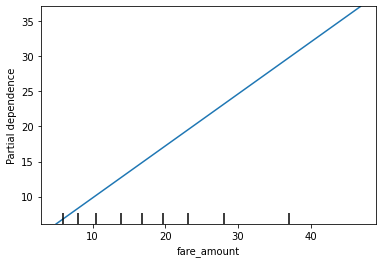

In [138]:

from sklearn.inspection import PartialDependenceDisplay

# Check exact feature name
print(dv.feature_names_)  # or dv.get_feature_names_out() for newer sklearn

# Then use the correct name if it's there, e.g.:
disp1 = PartialDependenceDisplay.from_estimator(
    lr,
    X_train.toarray(),
    ['fare_amount'],  # replace this with the exact name found above
    feature_names=dv.feature_names_  # pass actual feature names here
)
plt.show()

## fare amount us kind of directly impact duration

## SHAP

In [ ]:
conda remove pandas numpy
conda install pandas numpy
